In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [9]:
df = pd.read_csv("ecommerce.csv", encoding="ISO-8859-1")

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
df.shape

(541909, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [13]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [14]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
df = df.dropna(subset=["CustomerID"])

In [17]:
df.shape

(406829, 8)

In [18]:
df = df.drop_duplicates()

In [19]:
df.shape

(401604, 8)

In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.6 MB


CREATING REVENUE DATAFRAME FOR TO KNOW SALES PERFORMANCE!

In [22]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
 8   Revenue      401604 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.6 MB


In [24]:
df = df[df["Quantity"] > 0]

In [25]:
df = df[df["UnitPrice"] > 0]

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   Revenue      392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.0 MB


In [27]:
df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month_name()

df["MonthNum"] = df["InvoiceDate"].dt.month

df["Day"] = df["InvoiceDate"].dt.day_name()

df["Hour"] = df["InvoiceDate"].dt.hour

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   Revenue      392692 non-null  float64       
 9   Year         392692 non-null  int32         
 10  Month        392692 non-null  str           
 11  MonthNum     392692 non-null  int32         
 12  Day          392692 non-null  str           
 13  Hour         392692 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(3), int64(1), str(6)
memory usage: 40.4 MB


In [30]:
total_revenue = df["Revenue"].sum()

total_orders = df["InvoiceNo"].nunique()

total_customers = df["CustomerID"].nunique()

total_products = df["Quantity"].sum()

average_order = total_revenue / total_orders

In [31]:
print("Revenue :", total_revenue)

print("Orders :", total_orders)

print("Customers :", total_customers)

print("Products :", total_products)

print("Average Order :", average_order)

Revenue : 8887208.894000001
Orders : 18532
Customers : 4338
Products : 5152002
Average Order : 479.56016047917126



REVENUE BY MONTH!

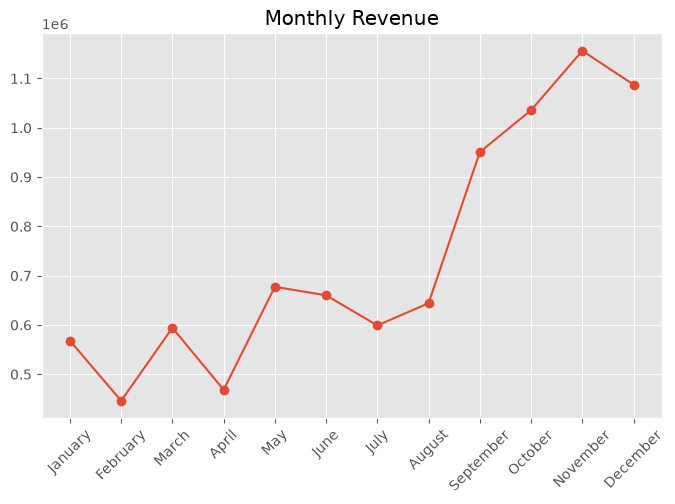

In [34]:
monthly_sales = (
    df.groupby(["MonthNum", "Month"])["Revenue"]
      .sum()
      .reset_index()
      .sort_values("MonthNum")
)

plt.figure(figsize=(8,5))
plt.plot(monthly_sales["Month"], monthly_sales["Revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.show()




TOP PRODUCTS!

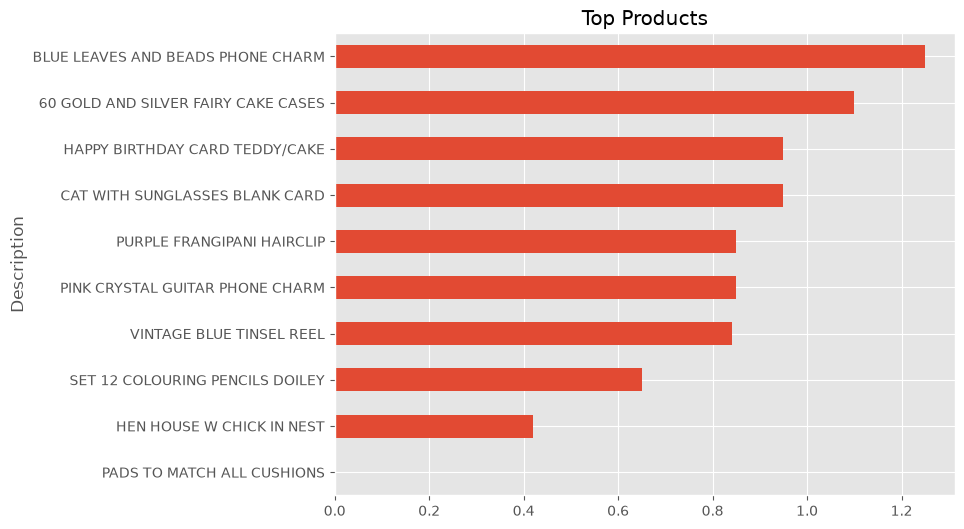

In [52]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

plt.figure(figsize=(8,6))
top_products.plot(kind="barh")
plt.title("Top Products")
plt.show()



TOP CUSTOMERS

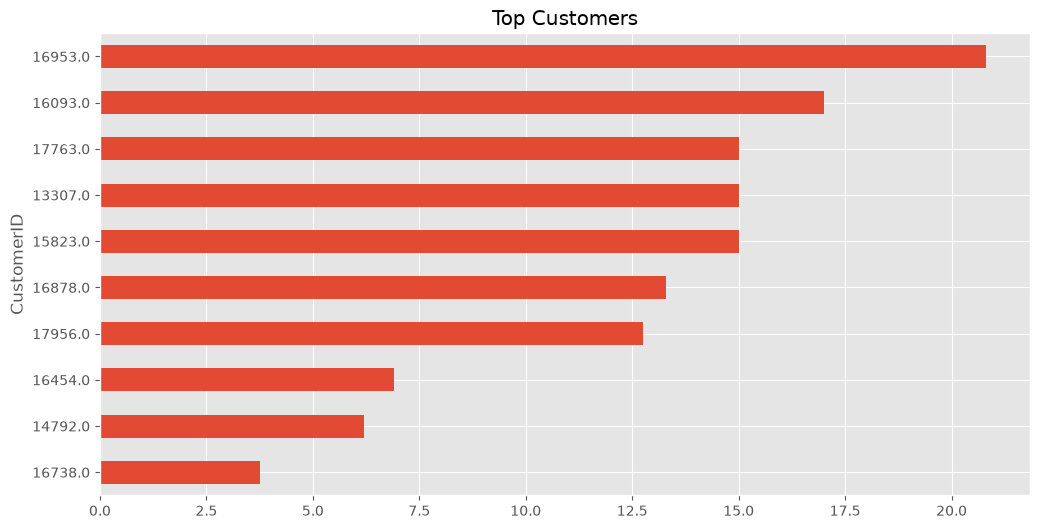

In [53]:
top_customer = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

plt.figure(figsize=(12,6))
top_customer.plot(kind="barh")
plt.title("Top Customers")
plt.show()



REVENUE SHARE BY TOP 10 PRODUCTS!


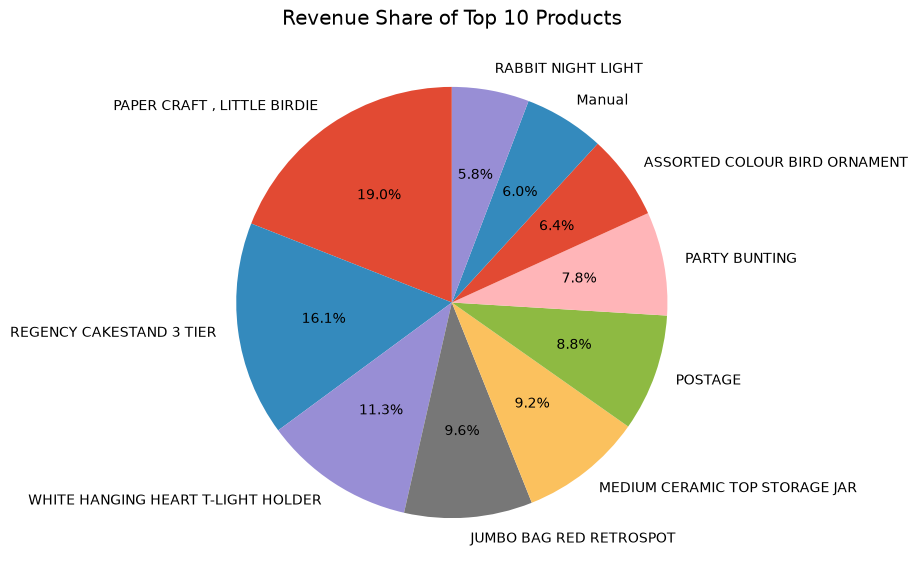

In [51]:
top10_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .nlargest(10)
)

plt.figure(figsize=(7,7))
plt.pie(top10_products,
        labels=top10_products.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Revenue Share of Top 10 Products")
plt.show()




REVENUE SHARE BY TOP 5 COUNTRIES!

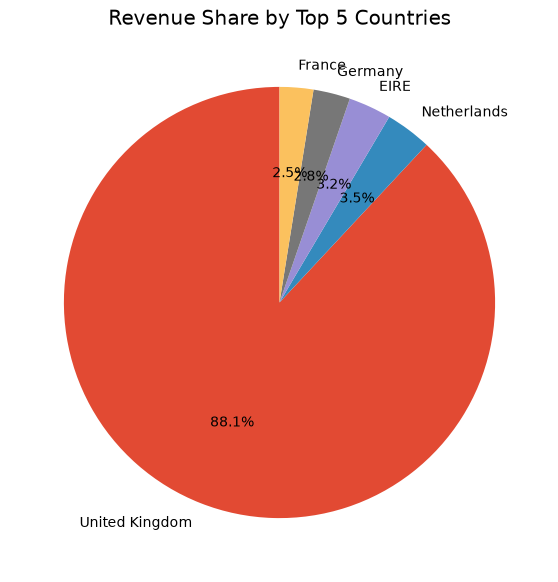

In [59]:
top5 = df.groupby("Country")["Revenue"].sum().nlargest(5)

plt.figure(figsize=(7,7))
plt.pie(top5,
        labels=top5.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Revenue Share by Top 5 Countries")
plt.show()

HEATMAP!

<Axes: >

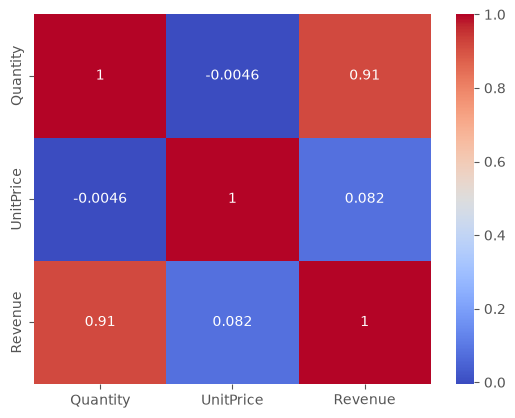

In [62]:
sns.heatmap(
    df[["Quantity","UnitPrice","Revenue"]].corr(),
    annot=True,
    cmap="coolwarm"
)

In [64]:
df.to_csv("cleaned_ecommerce.csv", index=False, encoding="utf-8")